In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, './src')
import post_production as pp

import seaborn as sns
from chainconsumer import ChainConsumer

In [2]:
ChainConsumer.__version__

'0.34.0'

In [3]:
def plot_corner_B(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,2,:].flatten()
        NN = chain[:,3,:].flatten()
        b1S = chain[:,4,:].flatten()
        s_fogS = chain[:,5,:].flatten()
        NS = chain[:,6,:].flatten()
        
        data = np.vstack([f_nl, b1N, b1S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$"]
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1B = chain[:,1,:].flatten()
        b2 = chain[:,2,:].flatten()
        bs = chain[:,3,:].flatten()
        a1 = chain[:,4,:].flatten()
        a2 = chain[:,5,:].flatten()
        
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [4]:
def plot_corner_B_prior(chain, pop=None, save=None, annotate=None, xy=(200,200)):
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
    
    f_nl = chain[:,0,:].flatten()
    b1B = chain[:,1,:].flatten()
    b2 = chain[:,2,:].flatten()
    bs = chain[:,3,:].flatten()
    a1 = chain[:,4,:].flatten()
    a2 = chain[:,5,:].flatten()
    
    data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
    labels=[r"$f_{\rm NL}$",
            r"$b_1^B$",
            r"$b_2$",
            r"$b_{s2}$",
            r"$\alpha_1$",
            r"$\alpha_2$"]
        
    nsample = 5000
    data2 = np.vstack([np.random.uniform(-1000, 1000, size=nsample),
                       np.random.normal(2.3, 0.5, size=nsample),
                       np.random.normal(-3.7, 5, size=nsample),
                       np.random.normal(-0.7, 0.6, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample),
                       np.random.uniform(-1.5, 1.5, size=nsample)]).transpose()    
    
    extents = {}
    for i,l in enumerate(labels):
        extents[l] = [data[:,i].min(), data[:,i].max()]
    #extents = None
    
    c = ChainConsumer()
    c.add_chain(data2, parameters=labels, name="Prior")
    c.add_chain(data, parameters=labels, name="Posterior")

    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True, True], bar_shade=[False, False], summary = True,
               tick_font_size=15, label_font_size=20)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    c.add_chain(data2, parameters=labels, name="Prior")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    

In [5]:
def plot_corner_PplusB(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$c_1 \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$c_1 \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, c1, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [6]:
def plot_corner_PplusB_noc1(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        a1N = chain[:,11,:].flatten()
        a2N = chain[:,12,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,13,:].flatten()
        bsS = chain[:,14,:].flatten()
        a1S = chain[:,15,:].flatten()
        a2S = chain[:,16,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm NGC)$",
                r"$\sigma_{\rm FoG}\, (\rm NGC)$",
                r"$N\, (\rm NGC)$",
                r"$b_1\, (\rm SGC)$",
                r"$\sigma_{\rm FoG}\, (\rm SGC)$",
                r"$N\, (\rm SGC)$"]
        
        tick_font_size=10
        label_font_size=15
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        a1 = chain[:,7,:].flatten()
        a2 = chain[:,8,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$"]
        
        tick_font_size=20
        label_font_size=25
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_size, label_font_size=label_font_size)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    if sample == "joint":
        data = np.vstack([f_nl, b1BN, b2N, bsN, a1N, a2N, b1BS, b2S, bsS, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B \, (\rm NGC)$",
                r"$b_2 \, (\rm NGC)$",
                r"$b_{s2} \, (\rm NGC)$",
                r"$\alpha_1 \, (\rm NGC)$",
                r"$\alpha_2 \, (\rm NGC)$",
                r"$b_1^B \, (\rm SGC)$",
                r"$b_2 \, (\rm SGC)$",
                r"$b_{s2} \, (\rm SGC)$",
                r"$\alpha_1 \, (\rm SGC)$",
                r"$\alpha_2 \, (\rm SGC)$"]
    else:
        data = np.vstack([f_nl, b1B, b2, bs, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    #c = ChainConsumer()
    #c.add_chain(data1, parameters=labels, name="FKP")
    ##c.add_chain(data2, parameters=labels, name="Optimal")
    #c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = False)
    #fig = c.plotter.plot(figsize="column")

    #fig.set_size_inches(3 + fig.get_size_inches())

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [7]:
def hist_chain(chain, length=12):
    f_nl = chain[:,0,:]
    
    for i in range(length):
        plt.hist(f_nl[:,i], bins=25, density=True, histtype='step', label=f'{i}')
    
    plt.legend()
    plt.show()
    
    R = pp.gelman_rubin_R(f_nl)
    print(R - 1)

In [8]:
def fNL_posterior_comparison_smooth(ch1, ch2, name1='FKP', name2='Optimal', save=None, ci95=None, annotate=None, xy=(100,100), xlim=None):
    from matplotlib.pyplot import rc
    import matplotlib.font_manager
    rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
    rc('mathtext', **{'fontset':'cm'})
    rc('text', usetex=True)
    rc('legend',**{'fontsize':'18'})
    matplotlib.rcParams['axes.linewidth'] = 1.5
    matplotlib.rcParams['axes.labelsize'] = 20
    matplotlib.rcParams['xtick.labelsize'] = 15
    matplotlib.rcParams['ytick.labelsize'] = 15
    matplotlib.rcParams['legend.fontsize'] = 15
    #matplotlib.rcParams['legend.title_fontsize'] = 25
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['xtick.minor.size'] = 2.5
    matplotlib.rcParams['ytick.minor.size'] = 2.5
    matplotlib.rcParams['xtick.major.width'] = 1.5
    matplotlib.rcParams['ytick.major.width'] = 1.5
    matplotlib.rcParams['xtick.minor.width'] = 1.5
    matplotlib.rcParams['ytick.minor.width'] = 1.5
    matplotlib.rcParams['axes.titlesize'] = 30
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    
    ch1 = ch1.flatten()
    ch2 = ch2.flatten()
    
    sns.distplot(ch1, hist=False, kde=True, label=name1,
                 color = 'tomato',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashed'})
    sns.distplot(ch2, hist=False, kde=True, label=name2,
                 color = 'darkblue',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dotted'})

    if ci95 is not None:
        plt.axvline(ci95[0,0], linestyle="dashed", color="tomato")
        plt.axvline(ci95[0,1], linestyle="dashed", color="tomato")
        plt.axvline(ci95[1,0], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[1,1], linestyle="dotted", color="darkblue")
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels')
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.xlabel("$f_{\\rm NL}$")
    plt.ylabel("$p( f_{\\rm NL} )$")
    plt.tick_params(axis='y', which='both', left=False, right=False, 
                    labelleft=False)
    plt.legend(frameon=False)
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

def fNL_posterior_3comparison_smooth(ch1, ch2, ch3, name1, name2, name3, save=None, ci95=None, annotate=None, xy=(100,100), xlim=None, loc=2):
    from matplotlib.pyplot import rc
    import matplotlib.font_manager
    rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
    rc('mathtext', **{'fontset':'cm'})
    rc('text', usetex=True)
    rc('legend',**{'fontsize':'18'})
    matplotlib.rcParams['axes.linewidth'] = 1.5
    matplotlib.rcParams['axes.labelsize'] = 20
    matplotlib.rcParams['xtick.labelsize'] = 15
    matplotlib.rcParams['ytick.labelsize'] = 15
    matplotlib.rcParams['legend.fontsize'] = 15
    #matplotlib.rcParams['legend.title_fontsize'] = 25
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['xtick.minor.size'] = 2.5
    matplotlib.rcParams['ytick.minor.size'] = 2.5
    matplotlib.rcParams['xtick.major.width'] = 1.5
    matplotlib.rcParams['ytick.major.width'] = 1.5
    matplotlib.rcParams['xtick.minor.width'] = 1.5
    matplotlib.rcParams['ytick.minor.width'] = 1.5
    matplotlib.rcParams['axes.titlesize'] = 30
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    
    ch1 = ch1.flatten()
    ch2 = ch2.flatten()
    ch3 = ch3.flatten()
    
    sns.distplot(ch1, hist=False, kde=True, label=name1,
                 color = 'tomato',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashed'})
    sns.distplot(ch2, hist=False, kde=True, label=name2,
                 color = 'darkblue',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dotted'})
    sns.distplot(ch3, hist=False, kde=True, label=name3,
                 color = 'green',
                 kde_kws={'linewidth': 1.5, 
                          'linestyle': 'dashdot'})

    if ci95 is not None:
        plt.axvline(ci95[0,0], linestyle="dashed", color="tomato")
        plt.axvline(ci95[0,1], linestyle="dashed", color="tomato")
        plt.axvline(ci95[1,0], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[1,1], linestyle="dotted", color="darkblue")
        plt.axvline(ci95[2,0], linestyle="dotted", color="green")
        plt.axvline(ci95[2,1], linestyle="dotted", color="green")
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels')
    
    if xlim is not None:
        plt.xlim(xlim)
    
    plt.xlabel("$f_{\\rm NL}$")
    plt.ylabel("$p( f_{\\rm NL} )$")
    plt.tick_params(axis='y', which='both', left=False, right=False, 
                    labelleft=False)
    plt.legend(frameon=False, loc=loc)
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [9]:
def plot_corner_PplusB_field(chain, sample, field=None, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        assert field is not None
        assert field in ['N', 'S']
        
        f_nl = chain[:,0,:].flatten()
        
        if field == 'N':
            b1P = chain[:,1,:].flatten()
            sigma_fog = chain[:,5,:].flatten()
            N = chain[:,6,:].flatten()
            
            b1B = chain[:,2,:].flatten()
            b2 = chain[:,9,:].flatten()
            bs = chain[:,10,:].flatten()
            c1 = chain[:,11,:].flatten()
            a1 = chain[:,12,:].flatten()
            a2 = chain[:,13,:].flatten()
            
            
        else:
            b1P = chain[:,3,:].flatten()
            sigma_fog = chain[:,7,:].flatten()
            N = chain[:,8,:].flatten()
        
            b1B = chain[:,4,:].flatten()
            b2 = chain[:,14,:].flatten()
            bs = chain[:,15,:].flatten()
            c1 = chain[:,16,:].flatten()
            a1 = chain[:,17,:].flatten()
            a2 = chain[:,18,:].flatten()
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
    data = np.vstack([f_nl, b1P, sigma_fog, N, b1B, b2, bs, c1, a1, a2]).transpose()
    labels=[r"$f_{\rm NL}$",
            r"$b_1^P$",
            r"$\sigma_{\rm FoG}$",
            r"$N$",
            "$b_1^B$",
            r"$b_2$",
            r"$b_{s2}$",
            r"$c_1$",
            r"$\alpha_1$",
            r"$\alpha_2$"]
        
    tick_font_sizeB =7
    label_font_sizeB=15
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

In [10]:
def plot_corner_PplusB_all(chain, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS, 
                          b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1\, (\rm N)$",
                r"$\sigma_{\rm FoG}\, (\rm N)$",
                r"$N\, (\rm N)$",
                r"$b_1\, (\rm S)$",
                r"$\sigma_{\rm FoG}\, (\rm S)$",
                r"$N\, (\rm S)$",
                r"$b_1^B \, (\rm N)$",
                r"$b_2 \, (\rm N)$",
                r"$b_{s2} \, (\rm N)$",
                r"$c_1 \, (\rm N)$",
                r"$\alpha_1 \, (\rm N)$",
                r"$\alpha_2 \, (\rm N)$",
                r"$b_1^B \, (\rm S)$",
                r"$b_2 \, (\rm S)$",
                r"$b_{s2} \, (\rm S)$",
                r"$c_1 \, (\rm S)$",
                r"$\alpha_1 \, (\rm S)$",
                r"$\alpha_2 \, (\rm S)$"]
        
        tick_font_sizeB =5
        label_font_sizeB=10
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N, 
                          b1B, b2, bs, c1, a1, a2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels)
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.configure(kde=[2.1], usetex=True, diagonal_tick_labels=True, shade=[True], bar_shade=[False], summary = True,
               tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB)
    fig = c.plotter.plot(figsize="column", extents=extents)

    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()
    
    
def plot_corner_PplusB_compare(chain, chain2, sample, pop=None, save=None, annotate=None, xy=(200,200), limits=None):
    
    assert sample in ["N", "S", "joint"]
    
    if pop is not None:
        chain = np.delete(chain, pop, -1)
        
    if sample == "joint":
        f_nl = chain[:,0,:].flatten()
        b1N = chain[:,1,:].flatten()
        s_fogN = chain[:,5,:].flatten()
        NN = chain[:,6,:].flatten()
        b1S = chain[:,3,:].flatten()
        s_fogS = chain[:,7,:].flatten()
        NS = chain[:,8,:].flatten()
        
        b1BN = chain[:,2,:].flatten()
        b2N = chain[:,9,:].flatten()
        bsN = chain[:,10,:].flatten()
        c1N = chain[:,11,:].flatten()
        a1N = chain[:,12,:].flatten()
        a2N = chain[:,13,:].flatten()
        
        b1BS = chain[:,4,:].flatten()
        b2S = chain[:,14,:].flatten()
        bsS = chain[:,15,:].flatten()
        c1S = chain[:,16,:].flatten()
        a1S = chain[:,17,:].flatten()
        a2S = chain[:,18,:].flatten()
        
        f_nl2 = chain2[:,0,:].flatten()
        b1N2 = chain2[:,1,:].flatten()
        s_fogN2 = chain2[:,5,:].flatten()
        NN2 = chain2[:,6,:].flatten()
        b1S2 = chain2[:,3,:].flatten()
        s_fogS2 = chain2[:,7,:].flatten()
        NS2 = chain2[:,8,:].flatten()
        
        b1BN2 = chain2[:,2,:].flatten()
        b2N2 = chain2[:,9,:].flatten()
        bsN2 = chain2[:,10,:].flatten()
        c1N2 = chain2[:,11,:].flatten()
        a1N2 = chain2[:,12,:].flatten()
        a2N2 = chain2[:,13,:].flatten()
        
        b1BS2 = chain2[:,4,:].flatten()
        b2S2 = chain2[:,14,:].flatten()
        bsS2 = chain2[:,15,:].flatten()
        c1S2 = chain2[:,16,:].flatten()
        a1S2 = chain2[:,17,:].flatten()
        a2S2 = chain2[:,18,:].flatten()
        
        data = np.vstack([f_nl, b1N, s_fogN, NN, b1S, s_fogS, NS, 
                          b1BN, b2N, bsN, c1N, a1N, a2N, b1BS, b2S, bsS, c1S, a1S, a2S]).transpose()
        data1 = np.vstack([f_nl2, b1N2, s_fogN2, NN2, b1S2, s_fogS2, NS2, 
                          b1BN2, b2N2, bsN2, c1N2, a1N2, a2N2, b1BS2, b2S2, bsS2, c1S2, a1S2, a2S2]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P\, (\rm N)$",
                r"$\sigma_{\rm FoG}\, (\rm N)$",
                r"$N\, (\rm N)$",
                r"$b_1^P\, (\rm S)$",
                r"$\sigma_{\rm FoG}\, (\rm S)$",
                r"$N\, (\rm S)$",
                r"$b_1^B \, (\rm N)$",
                r"$b_2 \, (\rm N)$",
                r"$b_{s^2} \, (\rm N)$",
                r"$c_1 \, (\rm N)$",
                r"$\alpha_1 \, (\rm N)$",
                r"$\alpha_2 \, (\rm N)$",
                r"$b_1^B \, (\rm S)$",
                r"$b_2 \, (\rm S)$",
                r"$b_{s^2} \, (\rm S)$",
                r"$c_1 \, (\rm S)$",
                r"$\alpha_1 \, (\rm S)$",
                r"$\alpha_2 \, (\rm S)$"]
        
        tick_font_sizeB =4
        label_font_sizeB=6
        
    else:
        f_nl = chain[:,0,:].flatten()
        b1P = chain[:,1,:].flatten()
        sigma_fog = chain[:,3,:].flatten()
        N = chain[:,4,:].flatten()
        b1B = chain[:,2,:].flatten()
        b2 = chain[:,5,:].flatten()
        bs = chain[:,6,:].flatten()
        c1 = chain[:,7,:].flatten()
        a1 = chain[:,8,:].flatten()
        a2 = chain[:,9,:].flatten()
        
        f_nl2 = chain2[:,0,:].flatten()
        b1P2 = chain2[:,1,:].flatten()
        sigma_fog2 = chain2[:,3,:].flatten()
        N2 = chain2[:,4,:].flatten()
        b1B2 = chain2[:,2,:].flatten()
        b22 = chain2[:,5,:].flatten()
        bs2 = chain2[:,6,:].flatten()
        c12 = chain2[:,7,:].flatten()
        a12 = chain2[:,8,:].flatten()
        a22 = chain2[:,9,:].flatten()
        
        data = np.vstack([f_nl, b1P, sigma_fog, N, 
                          b1B, b2, bs, c1, a1, a2]).transpose()
        data1 = np.vstack([f_nl2, b1P2, sigma_fog2, N2, 
                          b1B2, b22, bs2, c12, a12, a22]).transpose()
        labels=[r"$f_{\rm NL}$",
                r"$b_1^P$",
                r"$\sigma_{\rm FoG}$",
                r"$N$",
                r"$b_1^B$",
                r"$b_2$",
                r"$b_{s2}$",
                r"$c_1$",
                r"$\alpha_1$",
                r"$\alpha_2$"]
        
        tick_font_sizeB=20
        label_font_sizeB=25
        
    if limits is not None:
        assert len(limits) == len(labels)
        extents = {}
        for i,l in enumerate(labels):
            if limits[i] is None: continue
            extents[l] = limits[i]
    else: extents = None

    from matplotlib import colors
    green = colors.to_hex('green')
    darkblue = colors.to_hex('darkblue')
        
    c = ChainConsumer()
    c.add_chain(data, parameters=labels, name="$P+B$")
    #modify kde for a different smoothing (the higher, the smoother)
    #summary area used to write summaries in the plot
    c.add_chain(data1, parameters=labels, name="$P+{\\rm c}B$")
    #c.add_chain(data2, parameters=labels, name="Optimal")
    c.configure(kde=[2.1, 2.1], usetex=True, diagonal_tick_labels=True, shade=[False, False], bar_shade=[False, False], 
                summary = True, max_ticks=3, linestyles=['dashdot', 'dotted'], colors=[green,darkblue],
                tick_font_size=tick_font_sizeB, label_font_size=label_font_sizeB, legend_kwargs={'fontsize':25})
    fig = c.plotter.plot(figsize="column", extents=extents)
    
    if annotate is not None:
        plt.annotate(annotate, xy=xy, xycoords='axes pixels', fontsize=25)
    
    fig.set_size_inches(3 + fig.get_size_inches())
    
    
    if save is not None:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

# PcB results

## NGC FKP p=1

In [11]:
output = "bis-fits/output-PplusB-compression/"

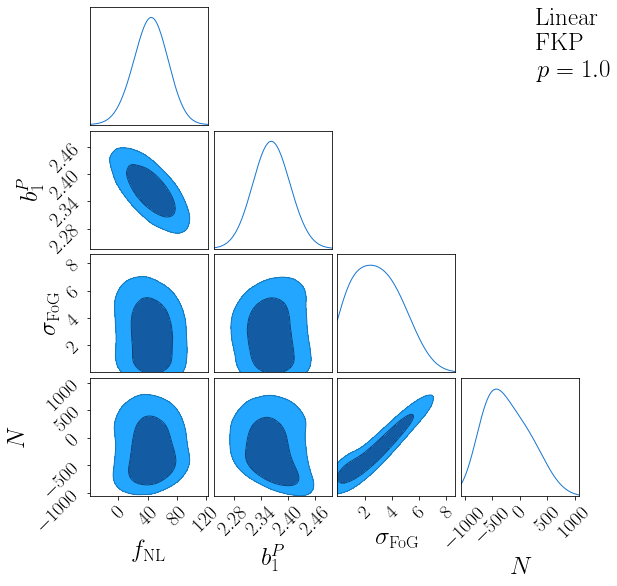

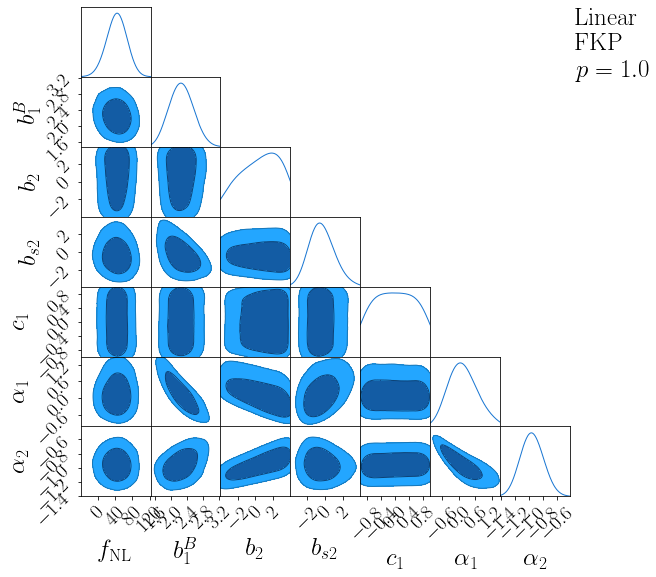

In [13]:
chain = np.load(output + "compression-9/NGC/data-SNsub/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = [], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC optimal P p=1

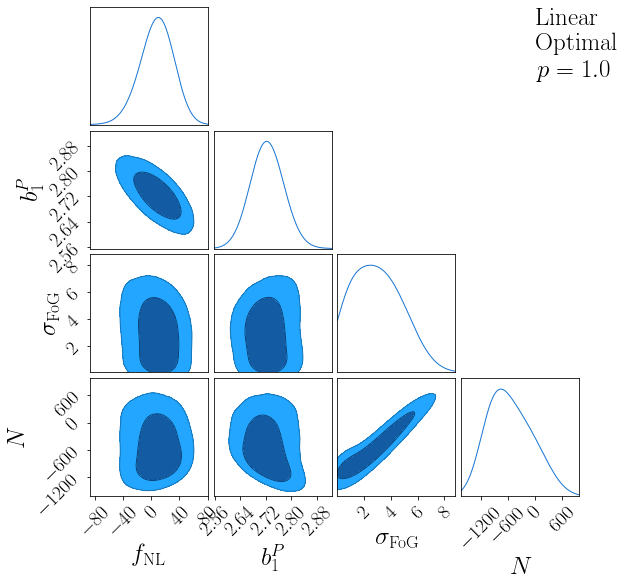

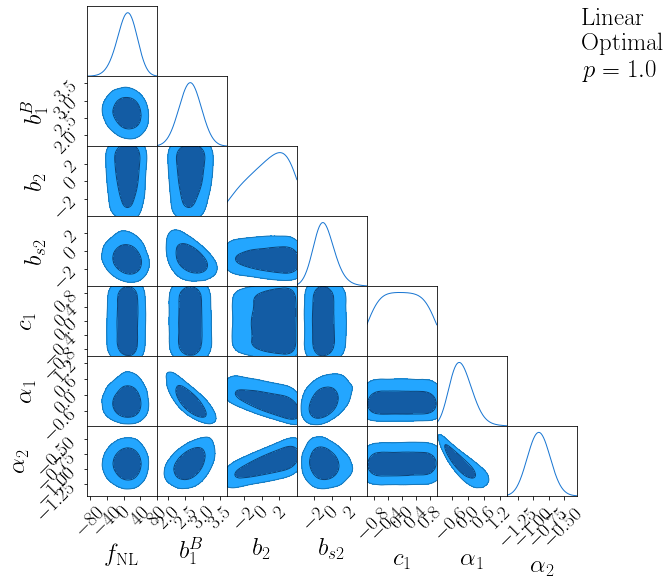

In [14]:
chain = np.load(output + "compression-9/NGC/data-SNsub/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC FKP p=1.6

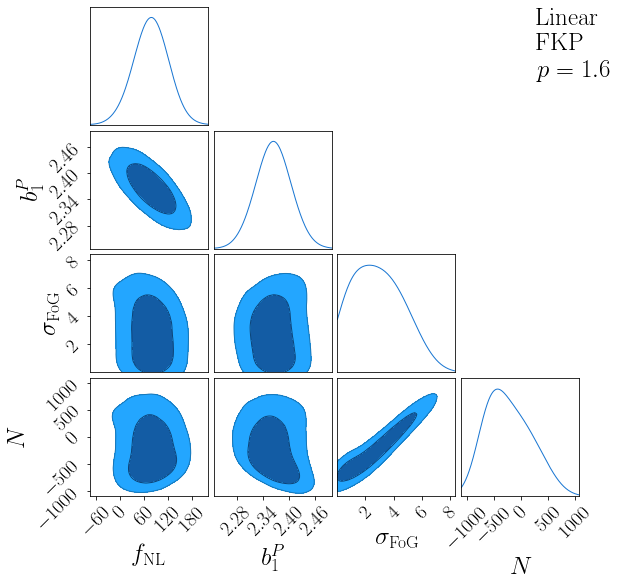

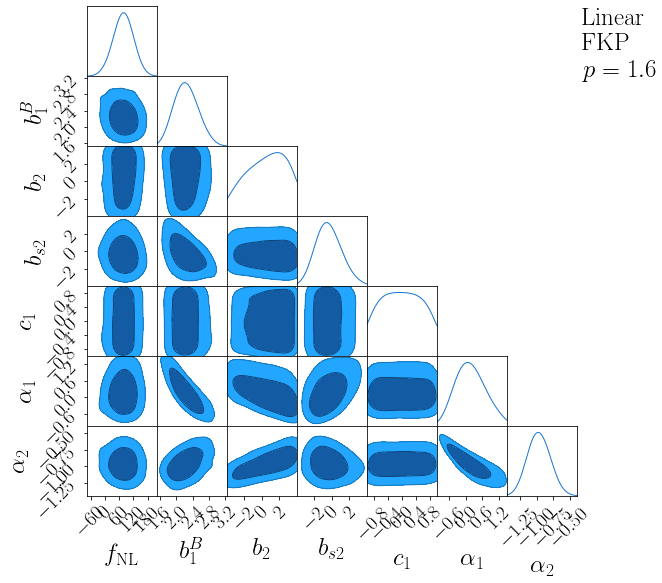

In [15]:
chain = np.load(output + "compression-9/NGC/data-SNsub/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## NGC optimal P p=1.6

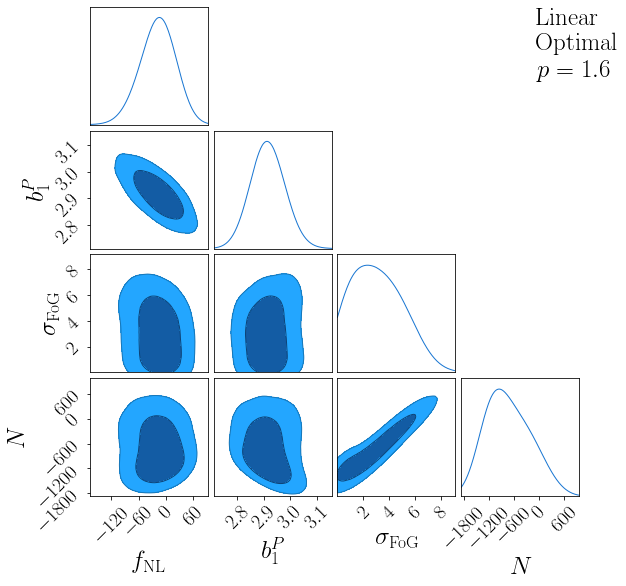

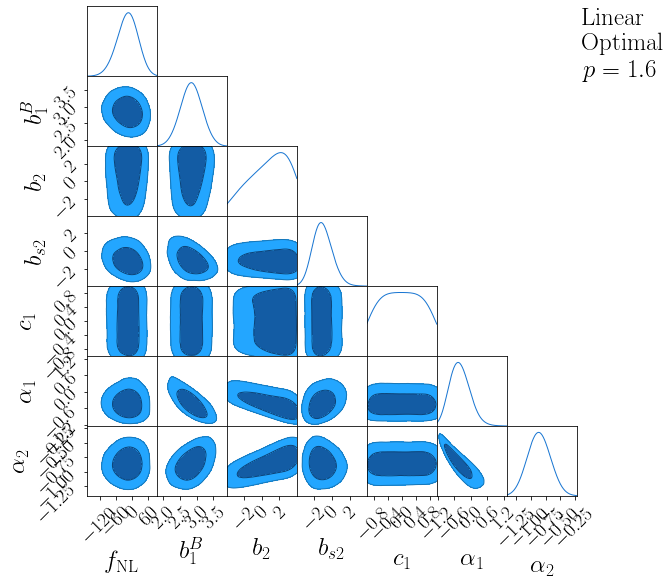

In [16]:
chain = np.load(output + "compression-9/NGC/data-SNsub/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = [5,7], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## SGC FKP p=1

In [17]:
output = "bis-fits/output-PplusB-compression/"

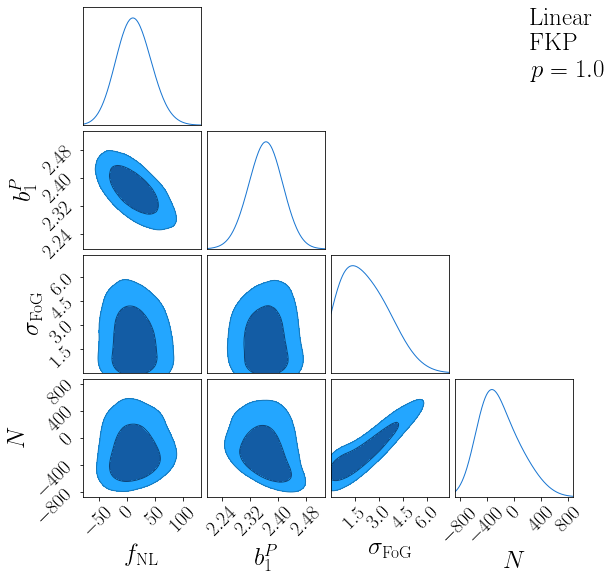

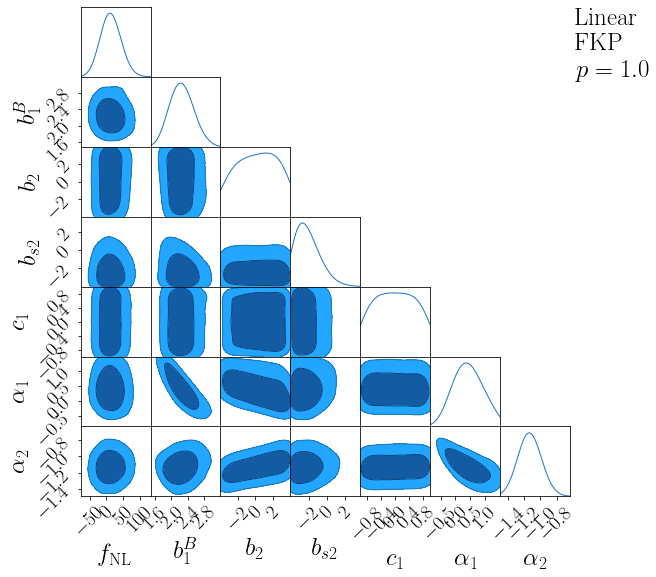

In [18]:
chain = np.load(output + "compression-9/SGC/data-SNsub/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "S", pop = [4,], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## SGC optimal P p=1

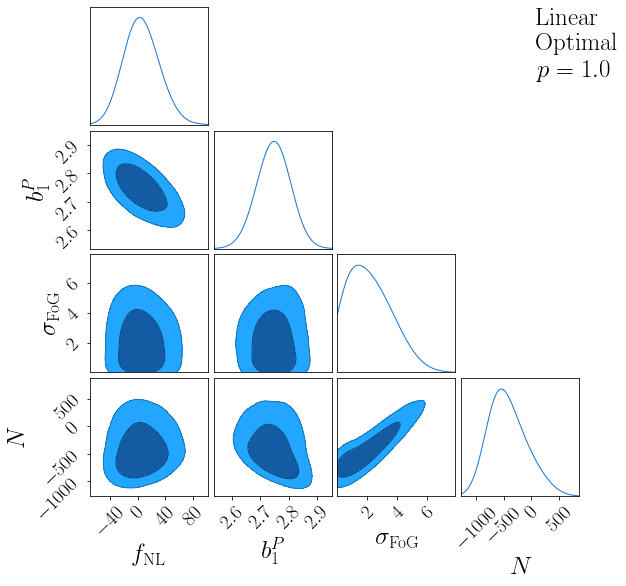

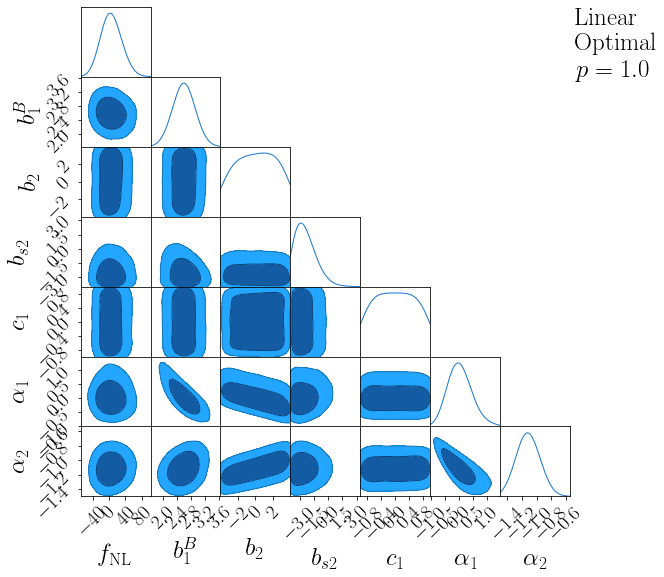

In [19]:
chain = np.load(output + "compression-9/SGC/data-SNsub/1.0/chain.npy")
plot_corner_PplusB(chain, "S", pop = [], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## SGC FKP p=1.6

In [20]:
output = "bis-fits/output-PplusB-compression/"

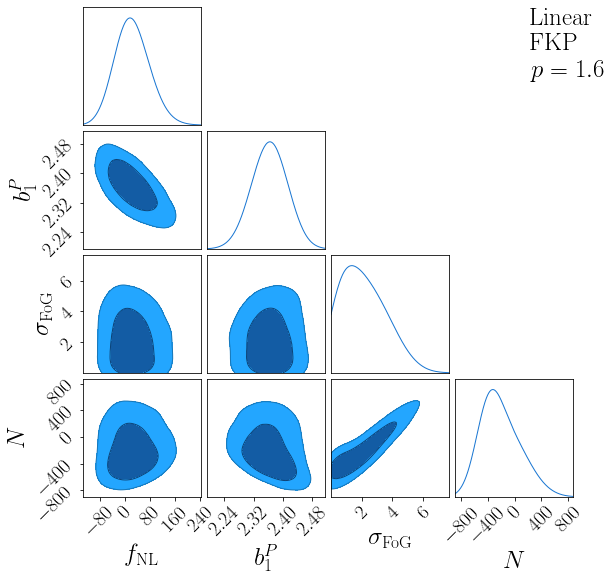

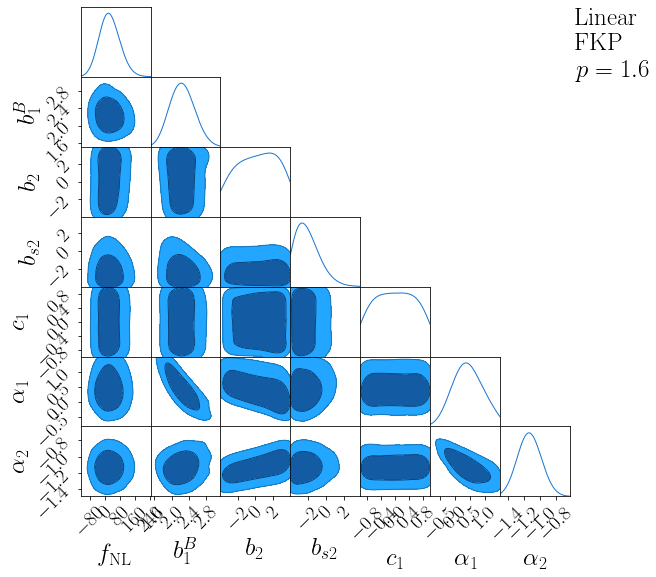

In [21]:
chain = np.load(output + "compression-9/SGC/data-SNsub/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## SGC optimal P p=1.6

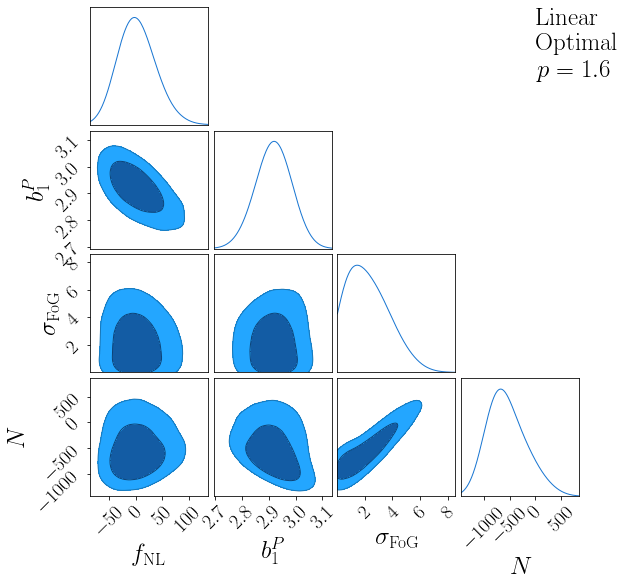

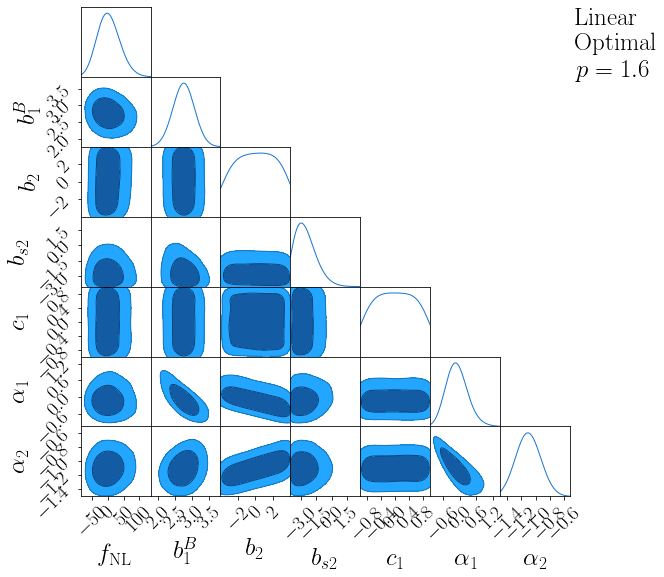

In [22]:
chain = np.load(output + "compression-9/SGC/data-SNsub/1.6/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## Joint FKP p=1

In [23]:
output = "bis-fits/output-PplusB-compression/"

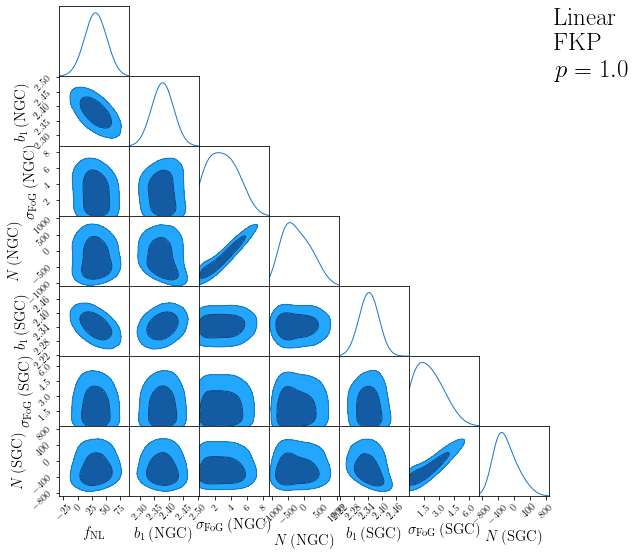

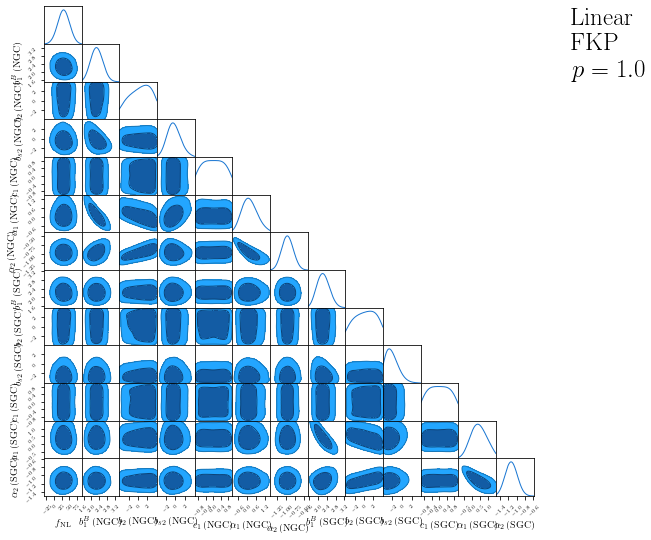

In [24]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "joint", pop = [2,4], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## Joint optimal P p=1

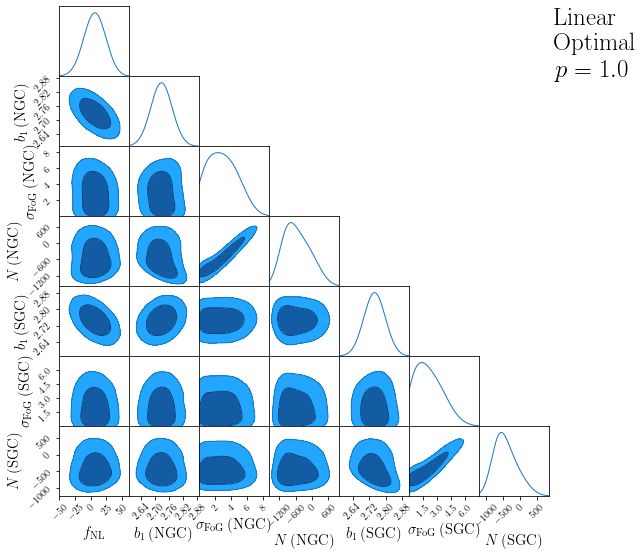

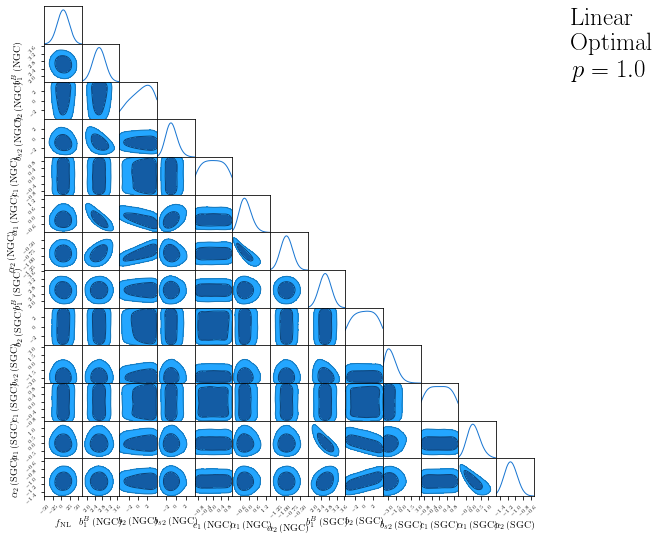

In [25]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/1.0/chain.npy")
plot_corner_PplusB(chain, "joint", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## Joint FKP p=1.6

In [26]:
output = "bis-fits/output-PplusB-compression/"

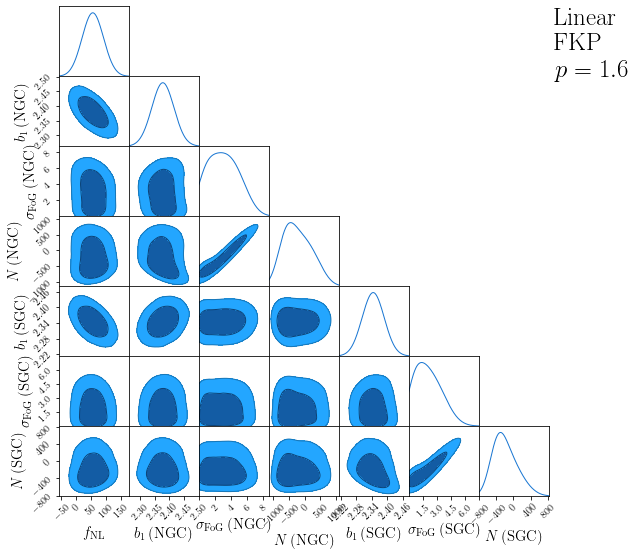

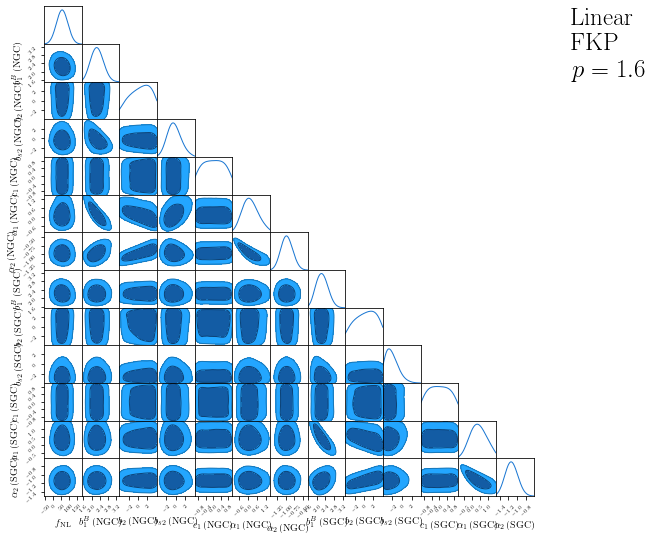

In [27]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "joint", pop = [3,], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## Joint optimal P p=1.6

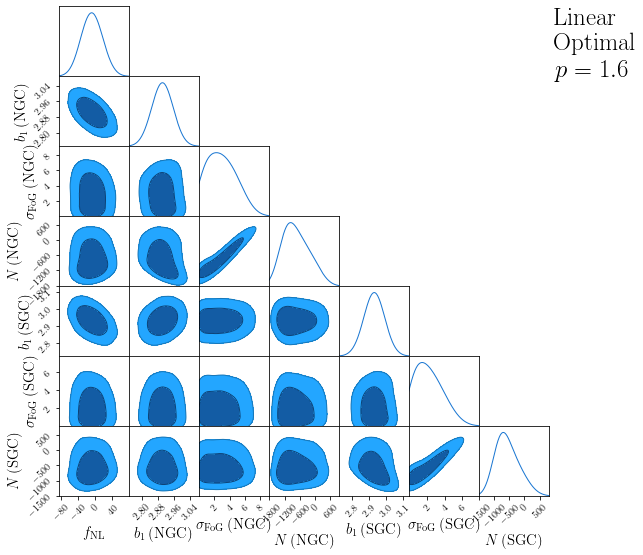

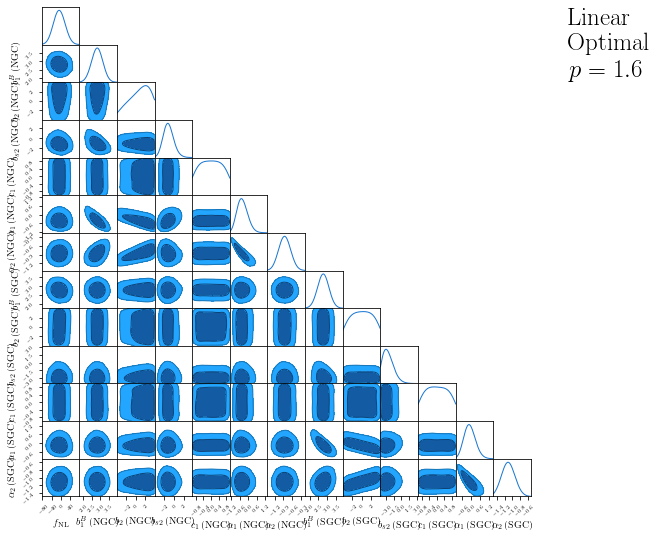

In [28]:
chain = np.load(output + "compression-N9-S9/joint/data-SNsub/1.6/chain.npy")
plot_corner_PplusB(chain, "joint", pop = [1,4], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

# $3 k_f$ binning Results

## NGC FKP p=1

In [29]:
output = "bis-fits/output-PplusB-s3rebin/"

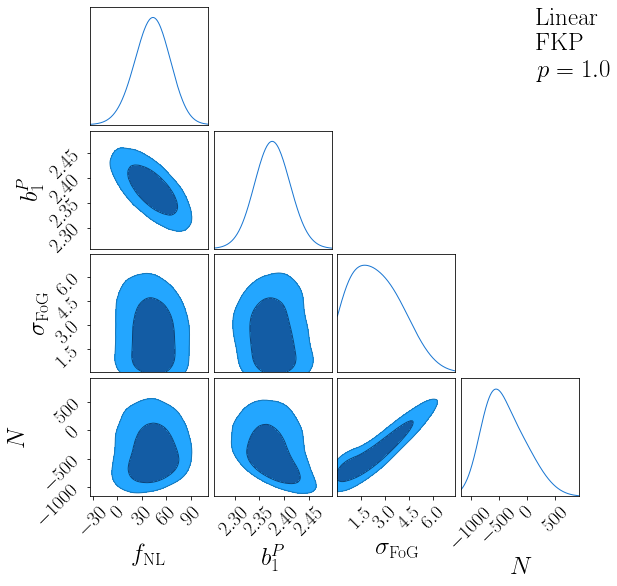

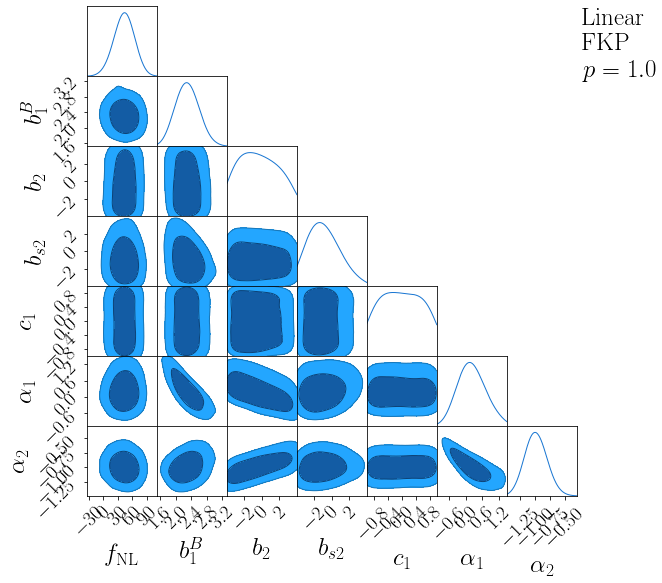

In [32]:
chain = np.load(output + "NGC/data-SNsub-fatsP/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC FKP p=1 with mask

In [33]:
output = "bis-fits/output-PplusB-s3rebin/"

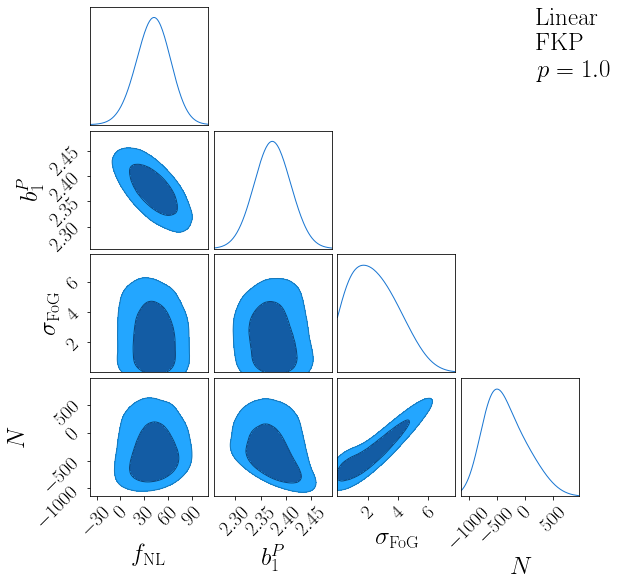

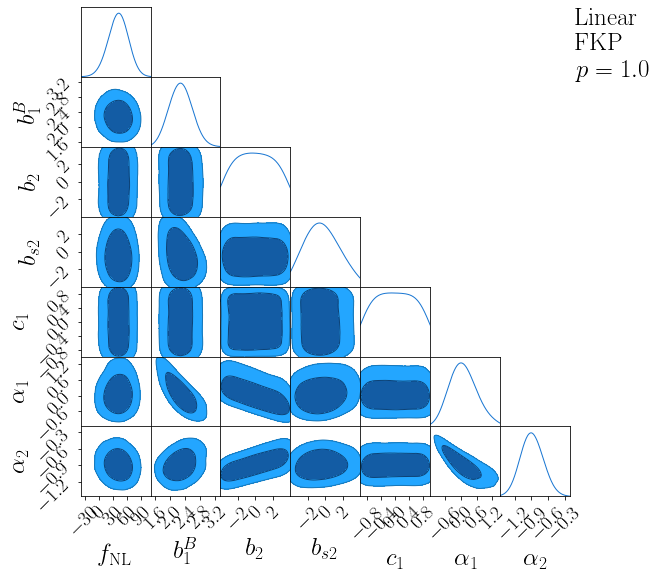

In [34]:
chain = np.load(output + "NGC/data-SNsub-mask/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC optimal P p=1

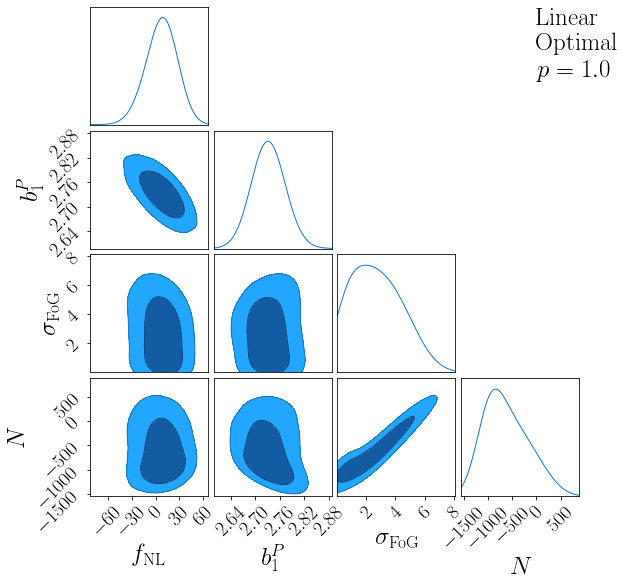

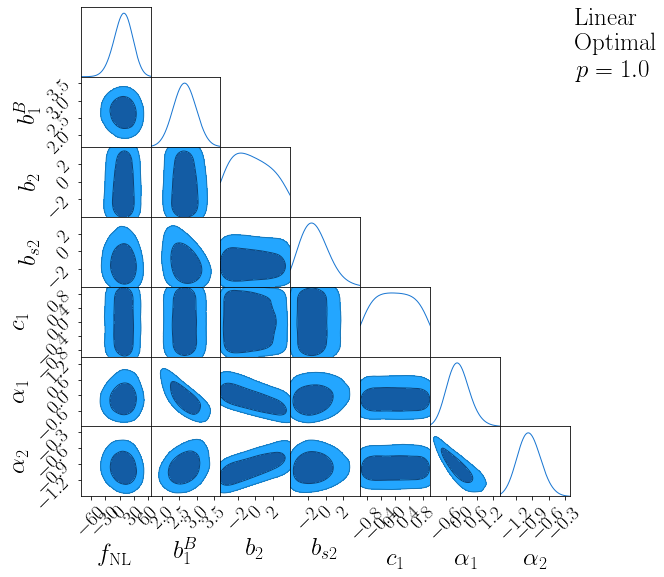

In [35]:
chain = np.load(output + "NGC/data-SNsub-fatsP/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC optimal P p=1 $b_2 \in [-20,20]$, $c_1 \in [-100,100]$

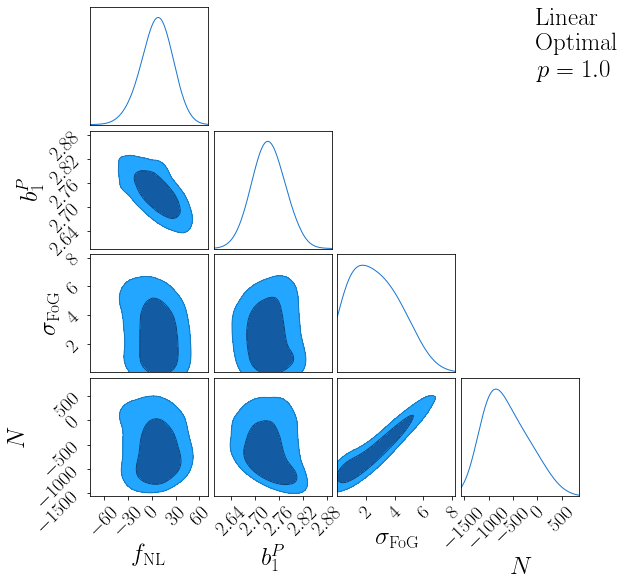

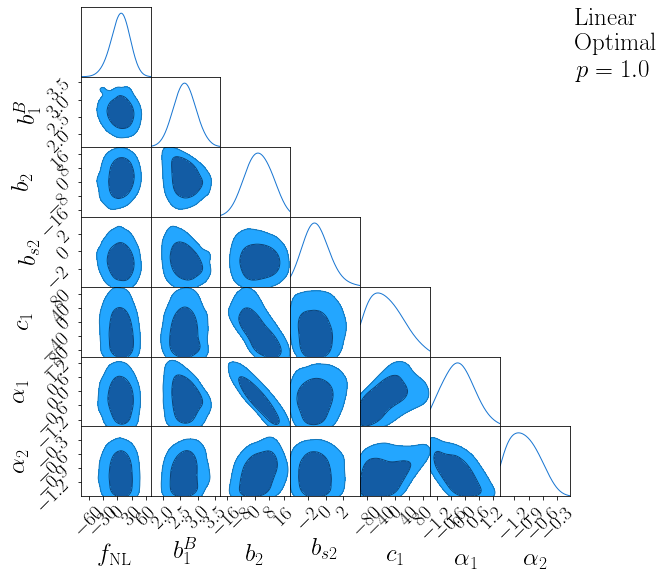

In [36]:
chain = np.load(output + "NGC/data-SNsub-b2c1large/1.0/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## NGC FKP p=1.6

In [37]:
output = "bis-fits/output-PplusB-s3rebin/"

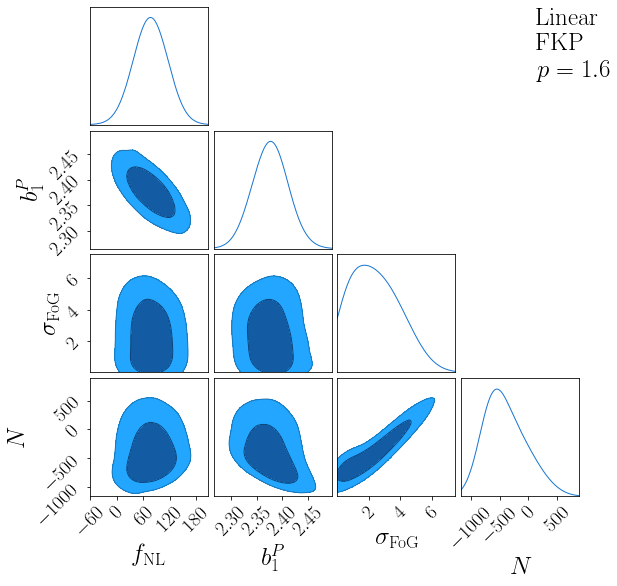

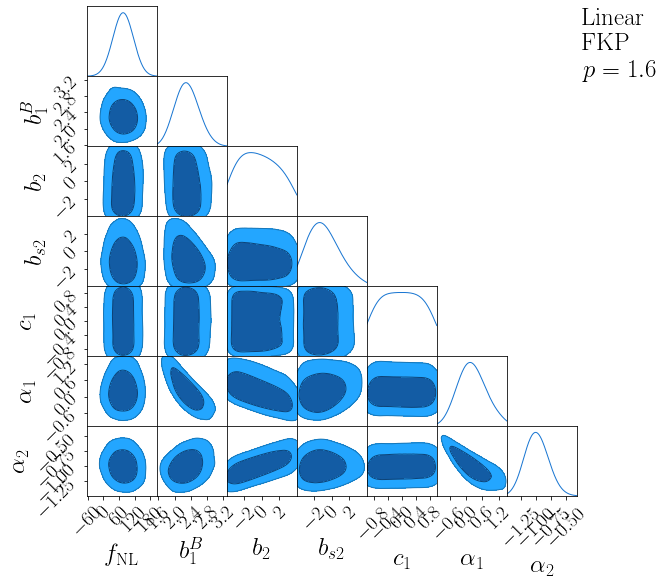

In [38]:
chain = np.load(output + "NGC/data-SNsub-fatsP/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## NGC optimal P p=1.6

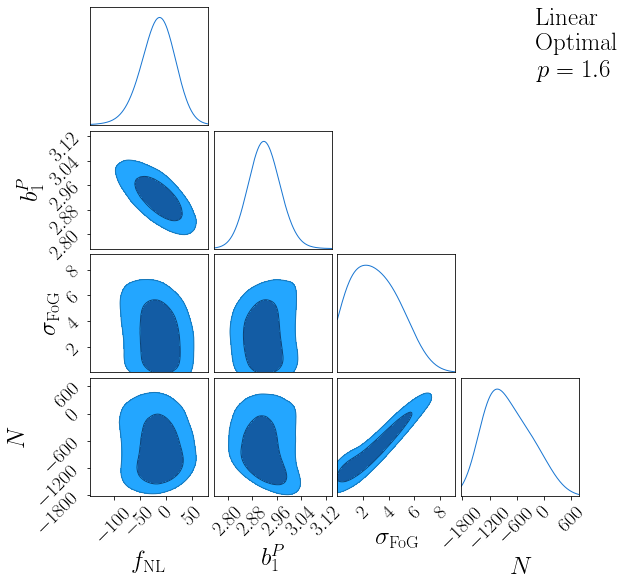

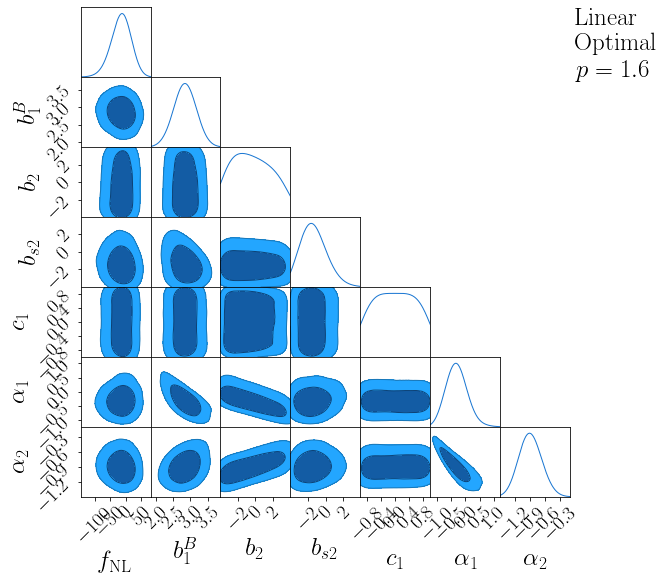

In [39]:
chain = np.load(output + "NGC/data-SNsub-fatsP/1.6/chain.npy")
plot_corner_PplusB(chain, "N", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## SGC FKP p=1

In [40]:
output = "bis-fits/output-PplusB-s3rebin/"

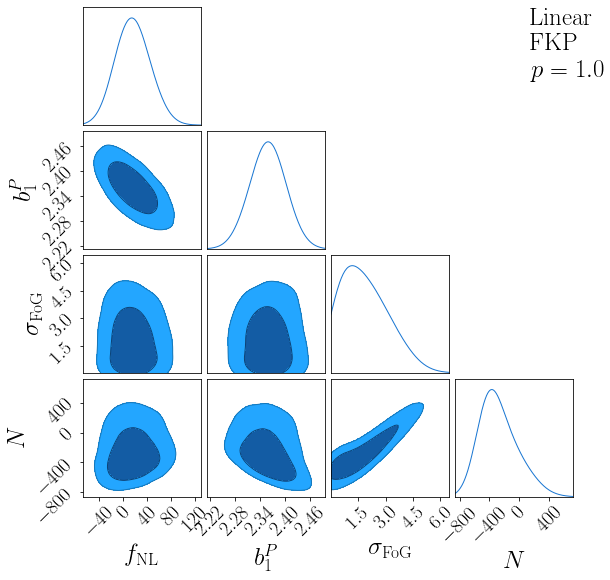

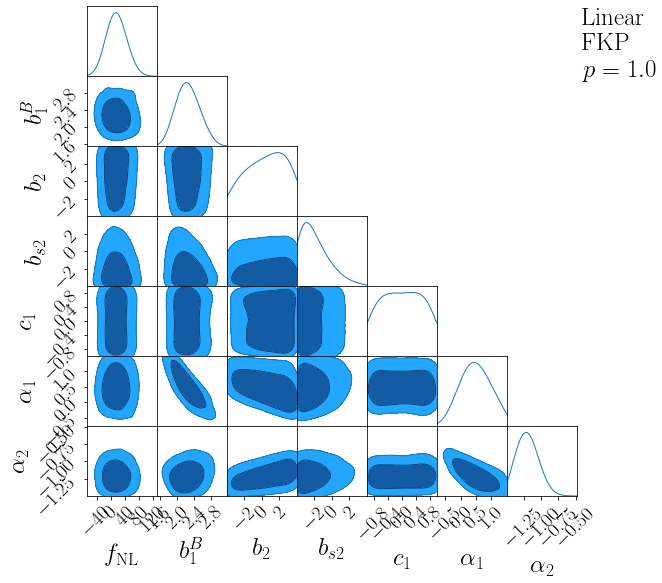

In [41]:
chain = np.load(output + "SGC/data-SNsub-fatsP/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## SGC optimal P p=1

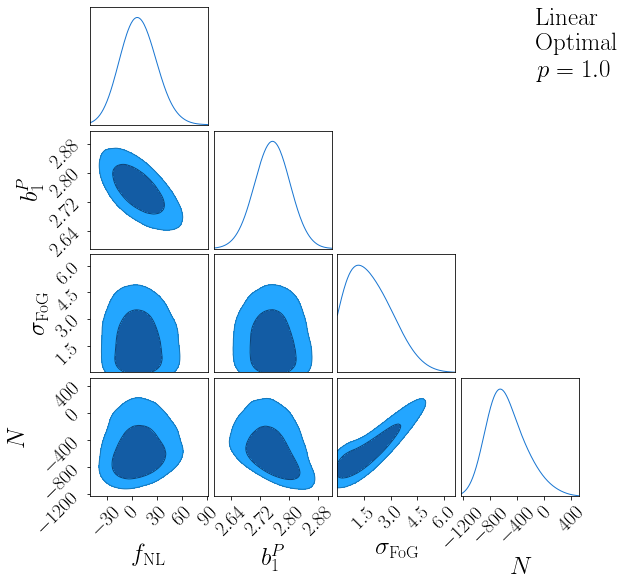

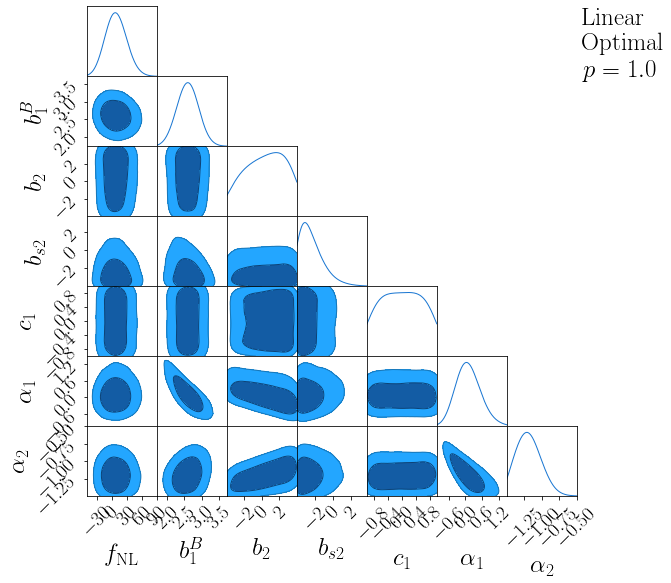

In [42]:
chain = np.load(output + "SGC/data-SNsub-fatsP/1.0/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## SGC FKP p=1.6

In [43]:
output = "bis-fits/output-PplusB-s3rebin/"

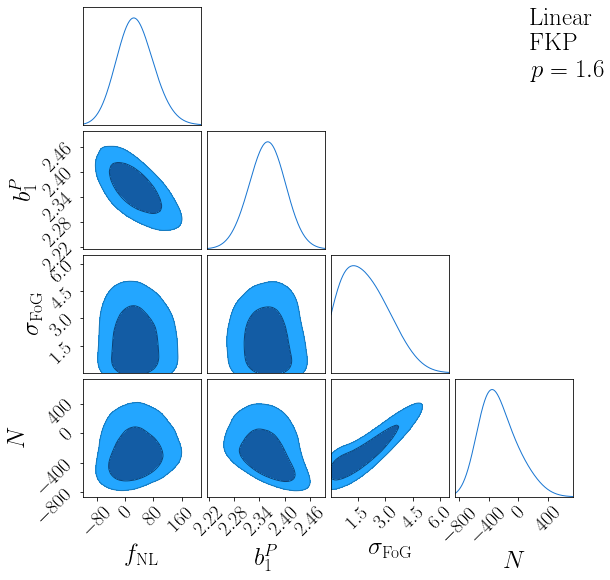

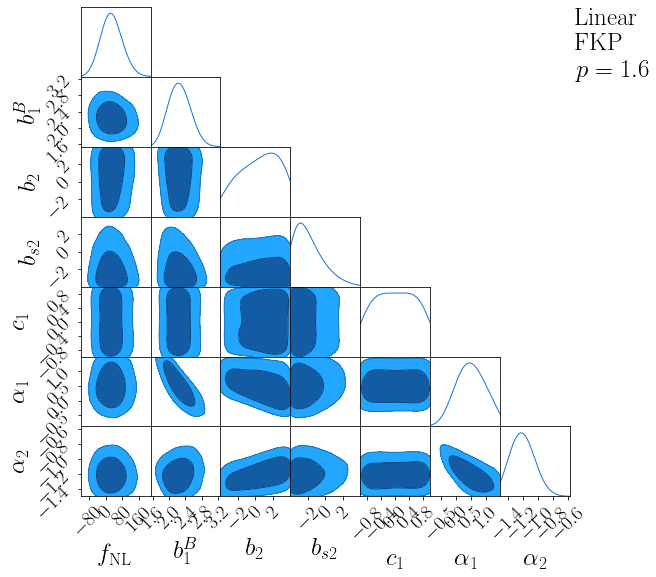

In [44]:
chain = np.load(output + "SGC/data-SNsub-fatsP/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## SGC optimal P p=1.6

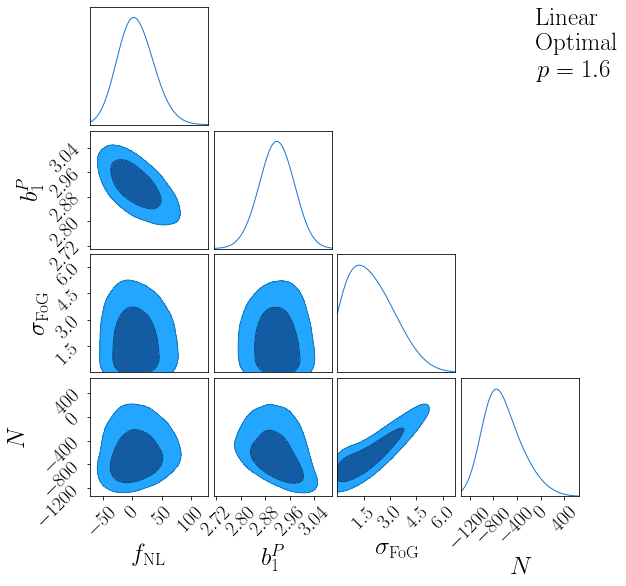

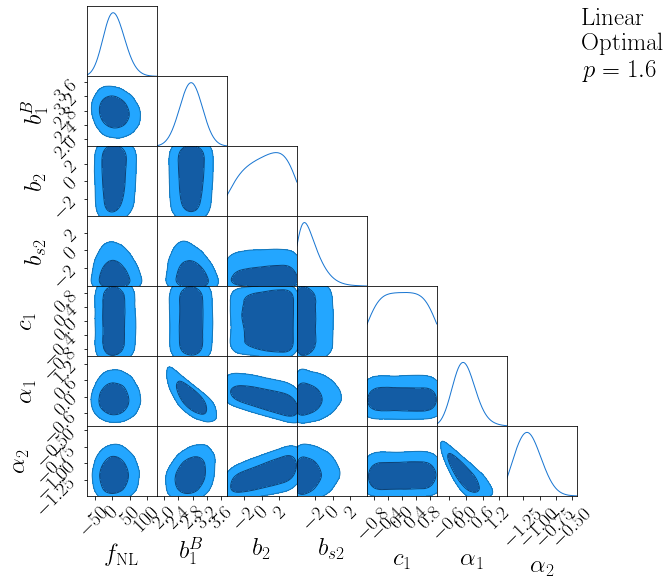

In [45]:
chain = np.load(output + "SGC/data-SNsub-fatsP/1.6/chain.npy")
plot_corner_PplusB(chain, "S", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## Joint FKP p=1

In [46]:
output = "bis-fits/output-PplusB-s3rebin/"

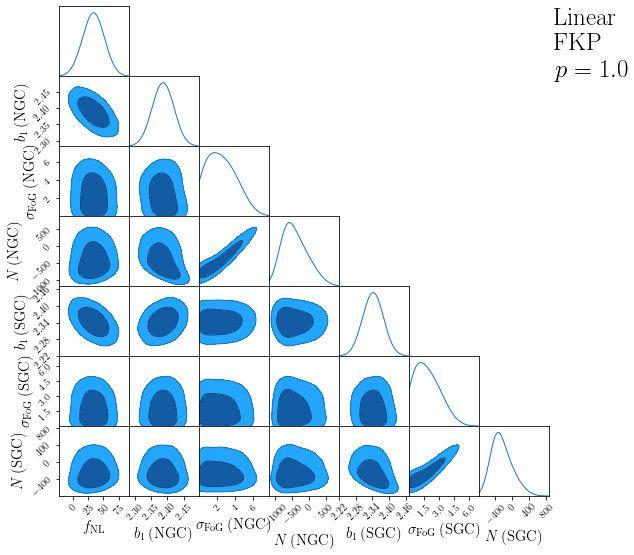

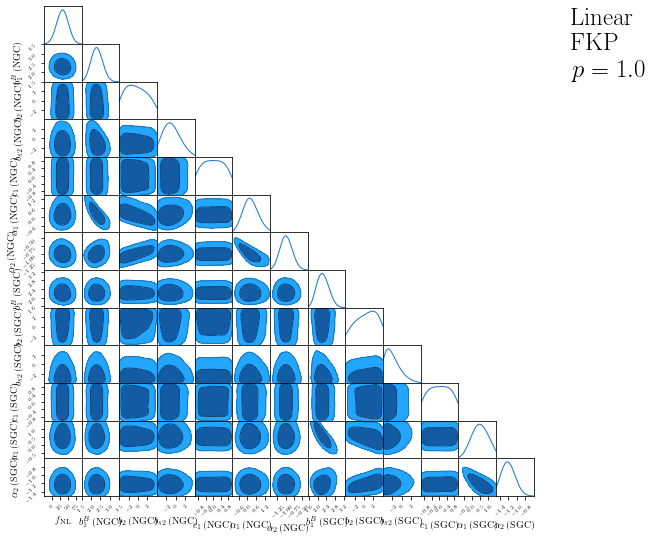

In [47]:
chain = np.load(output + "joint/data-SNsub/fkp/1.0/chain.npy")
plot_corner_PplusB(chain, "joint", pop = [4,6], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## Joint optimal P p=1

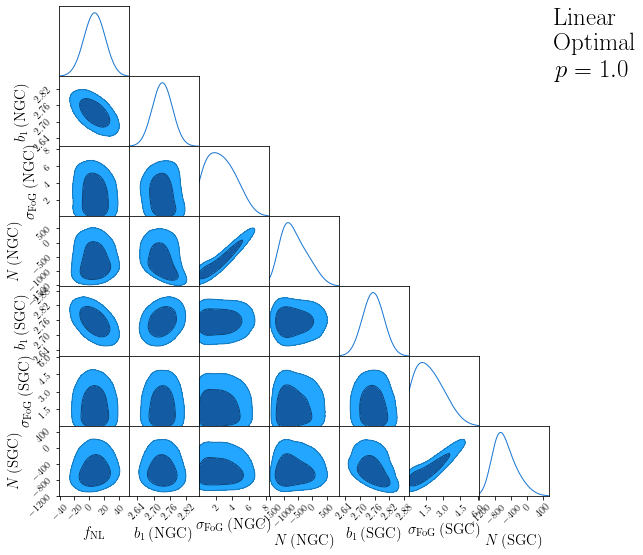

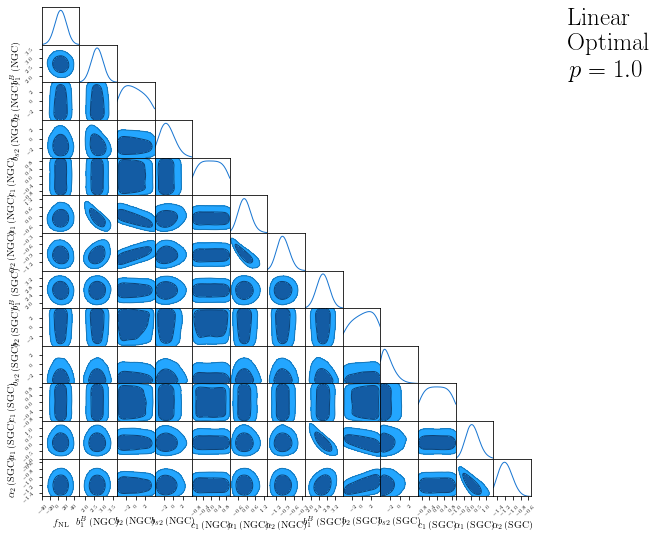

In [48]:
chain = np.load(output + "joint/data-SNsub/1.0/chain.npy")
plot_corner_PplusB(chain, "joint", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.0$", xy=(75, 420),
                  limits=None)

## Joint FKP p=1.6

In [49]:
output = "bis-fits/output-PplusB-s3rebin/"

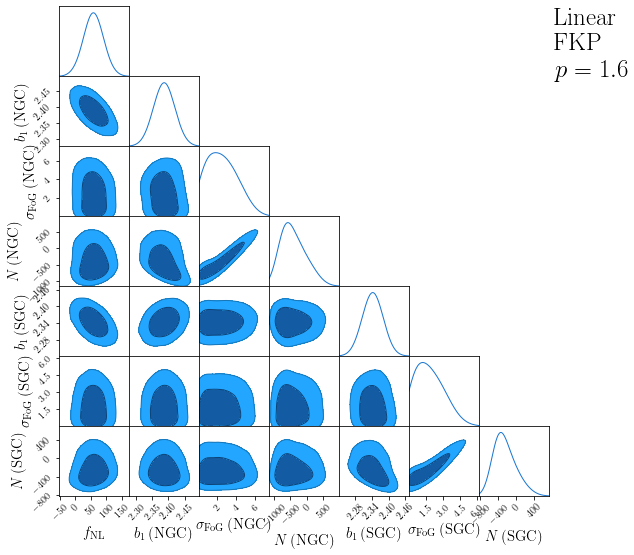

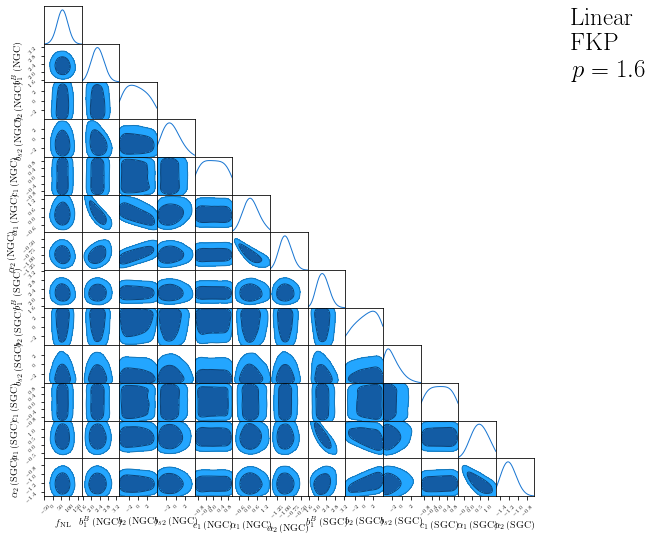

In [50]:
chain = np.load(output + "joint/data-SNsub/fkp/1.6/chain.npy")
plot_corner_PplusB(chain, "joint", pop = [0,9], save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm FKP}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

## Joint optimal P p=1.6

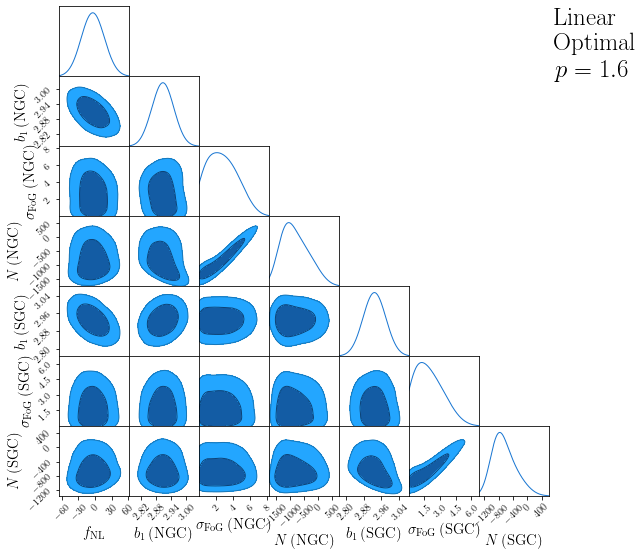

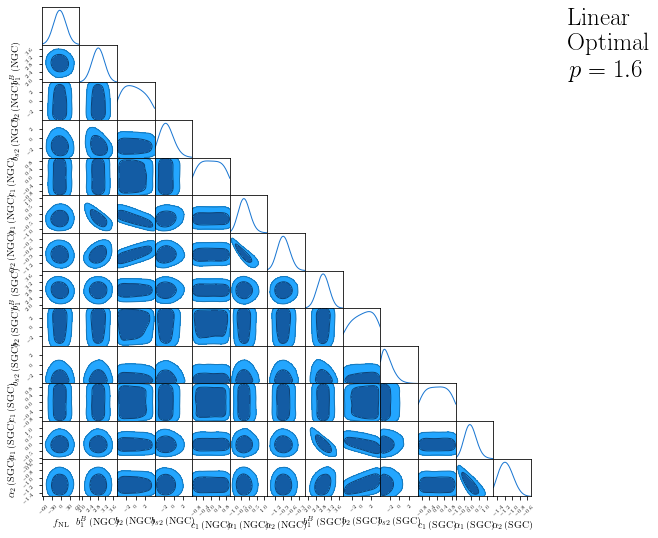

In [51]:
chain = np.load(output + "joint/data-SNsub/1.6/chain.npy")
plot_corner_PplusB(chain, "joint", pop = None, save = None,
                  annotate="${\\rm Linear}$ \n ${\\rm Optimal}$ \n $p=1.6$", xy=(75, 420),
                  limits=None)

# Compare corner

In [52]:
output_PcB = "bis-fits/output-PplusB-compression/"
output_PB  = "bis-fits/output-PplusB-s3rebin/"

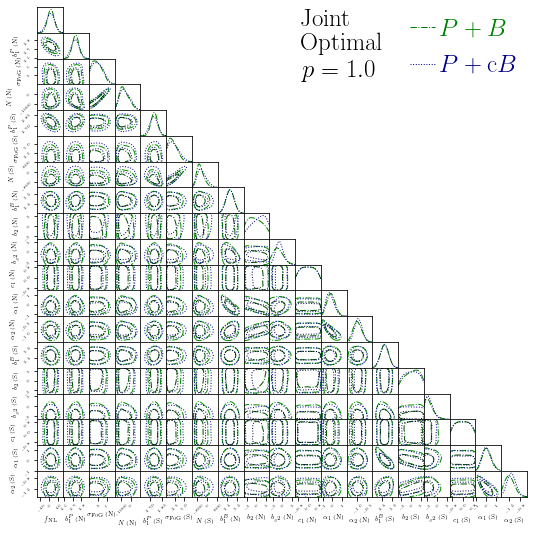

In [53]:
chain = np.load(output_PB + "joint/data-SNsub/1.0/chain.npy")
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/1.0/chain.npy")

#chain1 = np.delete(chain1, [1,9], -1)

plot_corner_PplusB_compare(chain[:,:,:], chain1[:,:,:], 'joint', pop=None, 
                           save=None, 
                           annotate="${\\rm Joint}$ \n ${\\rm Optimal}$ \n $p=1.0$", 
                           xy=(-200, 420), limits=None)
    

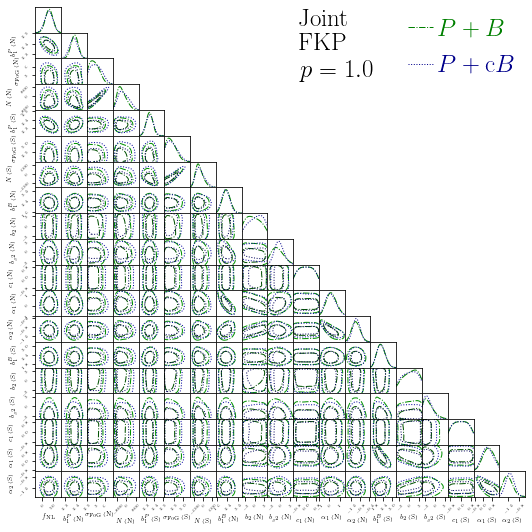

In [54]:
chain = np.load(output_PB + "joint/data-SNsub/fkp/1.0/chain.npy")
chain1 = np.load(output_PcB + "compression-N9-S9/joint/data-SNsub/fkp/1.0/chain.npy")

chain = np.delete(chain, [4,6], -1)
chain1 = np.delete(chain1, [4,2], -1)

plot_corner_PplusB_compare(chain[:,:,:], chain1[:,:,:], 'joint', pop=None, 
                           save=None, 
                           annotate="${\\rm Joint}$ \n ${\\rm FKP}$ \n $p=1.0$", 
                           xy=(-200, 420), limits=None)
    